### Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Imports
import sys, os, json, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from art.defences.trainer import AdversarialTrainer, AdversarialTrainerTRADESPyTorch

sys.path.append(str(Path.cwd().parents[1]))

from utils.functions import get_windowed_data
from utils.notebook import get_model_classifier, calculate_metrics, FilenameLoader, get_filename_from_path, freeze_attack_cols

/opt/anaconda3/envs/reu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Config

In [ ]:
# Input
checkpoint_name, data_name, save_name = FilenameLoader.rand_pos()

# Don't change
checkpoint_file = f"../../saved_models/{checkpoint_name}"
data_file = f"../../data/{data_name}"
save_path = f"./adv-data/{save_name}-trades"

os.makedirs(save_path, exist_ok=True)
collapsed = True

### Load hyperparameters

In [ ]:
# Constants
SEED = 0
TRAIN_SUBSAMPLE = 200_000
BATCH_SIZE = 64
NB_EPOCHS = 5
RATIO = 0.6

TRAIN_EPS = [0.03, 0.07, 0.12, 0.18, 0.25]
PGD_STEPS = 5
PGD_STEP_SIZE_FRAC = 1/3

EVAL_EPS = [0.02, 0.05, 0.08, 0.12, 0.16, 0.2, 0.25, 0.3]

np.random.seed(SEED)


### Load model and data

In [ ]:
# Load data
(x_train, y_train), (x_test, y_test), fed_dataset, scaler = get_windowed_data(
    data_file, normalize=True, train_perc=80
)
x_train_np, y_train_np = x_train.numpy(), y_train.numpy()
x_test_np, y_test_np = x_test.numpy(), y_test.numpy()

# Load model
model, classifier = get_model_classifier(checkpoint_file, collapsed=collapsed)
classifier._reduce_labels = True

# Create a smaller window
rng = np.random.default_rng(SEED)
train_idx = rng.choice(len(x_train_np), size=min(TRAIN_SUBSAMPLE, len(x_train_np)), replace=False)
x_train_sub, y_train_sub = x_train_np[train_idx], y_train_np[train_idx]
print(f"Training on {len(x_train_sub)} / {len(x_train_np)} windows")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/reu/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Checkpoint path exists!
Training on 200000 / 499092 windows


### Evaluation Helper Function

In [10]:
def evaluate_robustness(classifier, x_np, y_np, eps_values, attack_cls=FastGradientMethod,
                         max_iter=PGD_STEPS, eps_step_frac=PGD_STEP_SIZE_FRAC):
    """
    Sweep an untargeted attack over several eps values, scored against the true
    labels (a correctly-untargeted attack, unlike utils.notebook.adv_test).
    """
    results = []
    for eps in eps_values:
        kwargs = dict(eps=eps)
        if attack_cls is ProjectedGradientDescent:
            kwargs["eps_step"] = eps_step_frac * eps
            kwargs["max_iter"] = max_iter
            kwargs["verbose"] = False
        # Freeze cols for freezing the receive time col
        attack = freeze_attack_cols(attack_cls(classifier, **kwargs))
        x_adv = attack.generate(x=x_np, y=y_np)
        preds = classifier.predict(x_adv, batch_size=BATCH_SIZE)
        metrics = calculate_metrics(preds, y_np)
        metrics["eps"] = eps
        results.append(metrics)
        print(f"  eps={eps:<5} f1={metrics['f1']:.4f}  recall={metrics['recall']:.4f}  fpr={metrics['falsePositiveRate']:.4f}")
    return results

### Ensemble Adversarial Training

#### Baseline (before training)

In [11]:
print("=== Baseline clean ===")
baseline_clean_preds = classifier.predict(x_test_np, batch_size=BATCH_SIZE)
baseline_clean = calculate_metrics(baseline_clean_preds, y_test_np)

print("=== Baseline under attack (FGSM sweep, true labels) ===")
baseline_sweep = evaluate_robustness(classifier, x_test_np, y_test_np, EVAL_EPS)

=== Baseline clean ===
=== Baseline under attack (FGSM sweep, true labels) ===
  eps=0.02  f1=0.9621  recall=0.9297  fpr=0.0013
  eps=0.05  f1=0.8870  recall=0.8815  fpr=0.0448
  eps=0.08  f1=0.6204  recall=0.8280  fpr=0.3555
  eps=0.12  f1=0.3743  recall=0.7492  fpr=0.9524
  eps=0.16  f1=0.3330  recall=0.6623  fpr=0.9786
  eps=0.2   f1=0.2952  recall=0.5772  fpr=0.9863
  eps=0.25  f1=0.2516  recall=0.4808  fpr=0.9896
  eps=0.3   f1=0.2138  recall=0.4005  fpr=0.9917


#### Training

In [ ]:
attacks = [
    ProjectedGradientDescent(classifier, eps=eps, eps_step=eps * PGD_STEP_SIZE_FRAC,
                              max_iter=PGD_STEPS, targeted=False, verbose=False)
    for eps in TRAIN_EPS
]
# attacks = [
#     FastGradientMethod(classifier, eps=eps, targeted=False)
#     for eps in TRAIN_EPS
# ]
# trainer = AdversarialTrainer(classifier, attacks=attacks, ratio=RATIO)
for attack in attacks:
    trainer = AdversarialTrainerTRADESPyTorch(classifier, attack, beta=RATIO)
    trainer.fit(x_train_sub, y_train_sub, batch_size=BATCH_SIZE, nb_epochs=NB_EPOCHS)

Training on 200000 windows, 5 epochs, ensemble eps=[0.03, 0.7, 0.12, 0.18, 0.25], PGD steps=5, ratio=0.6


Adversarial training epochs: 100%|██████████| 5/5 [14:01<00:00, 168.20s/it]


#### Baseline (after training)

In [30]:
print("=== After robust training: clean ===")
after_clean_preds = classifier.predict(x_test_np, batch_size=BATCH_SIZE)
after_clean = calculate_metrics(after_clean_preds, y_test_np)
print(f"  clean f1={after_clean['f1']:.4f} (baseline was {baseline_clean['f1']:.4f})")

print("=== After robust training: under attack (FGSM sweep, true labels) ===")
after_sweep = evaluate_robustness(classifier, x_test_np, y_test_np, EVAL_EPS)

=== After robust training: clean ===
  clean f1=0.9005 (baseline was 0.9765)
=== After robust training: under attack (FGSM sweep, true labels) ===
  eps=0.02  f1=0.8762  recall=0.7803  fpr=0.0003
  eps=0.05  f1=0.8433  recall=0.7298  fpr=0.0005
  eps=0.08  f1=0.8190  recall=0.6943  fpr=0.0005
  eps=0.12  f1=0.8032  recall=0.6723  fpr=0.0007
  eps=0.16  f1=0.8023  recall=0.6713  fpr=0.0009
  eps=0.2   f1=0.8128  recall=0.6873  fpr=0.0016
  eps=0.25  f1=0.8261  recall=0.7203  fpr=0.0100
  eps=0.3   f1=0.7505  recall=0.7591  fpr=0.1116


### Plotting

../../data/RandomPos_0709.csv


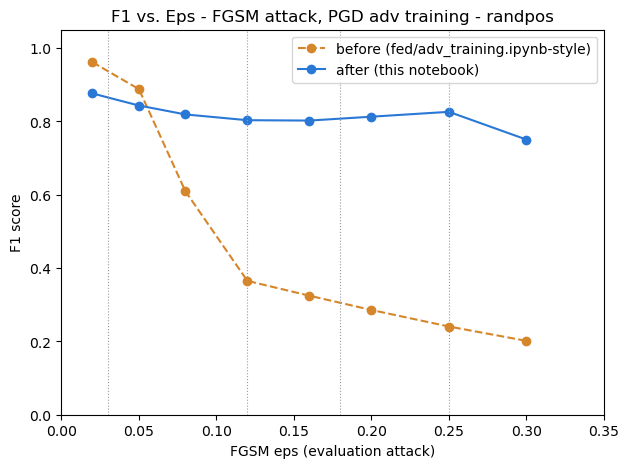

In [45]:
print(data_file)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(EVAL_EPS, [r["f1"] for r in baseline_sweep], "o--", label="before (fed/adv_training.ipynb-style)", color="#d6862a")
ax.plot(EVAL_EPS, [r["f1"] for r in after_sweep], "o-", label="after (this notebook)", color="#2a78d6")
for eps in TRAIN_EPS:
    ax.axvline(eps, color="#999999", linestyle=":", linewidth=0.8)
ax.set_xlabel("FGSM eps (evaluation attack)")
ax.set_ylabel("F1 score")
ax.set_title(f"F1 vs. Eps - FGSM attack, PGD adv training - {save_name}")
ax.set_xlim(0, 0.35)
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

### Save Checkpoint

In [37]:
ckpt_out = f"{save_path}/{get_filename_from_path(checkpoint_file)}_adv_trained.ckpt"
torch.save(model.learner.state_dict(), ckpt_out)

summary = {
    "checkpoint_in": checkpoint_file,
    "checkpoint_out": ckpt_out,
    "data_file": data_file,
    "config": {
        "train_subsample": len(x_train_sub),
        "batch_size": BATCH_SIZE,
        "nb_epochs": NB_EPOCHS,
        "ratio": RATIO,
        "train_eps": TRAIN_EPS,
        "pgd_steps": PGD_STEPS,
    },
    "baseline_clean_f1": baseline_clean["f1"],
    "after_clean_f1": after_clean["f1"],
    "baseline_sweep": baseline_sweep,
    "after_sweep": after_sweep,
}
with open(f"{save_path}/results.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved robust checkpoint to {ckpt_out}")


Saved robust checkpoint to ./adv-data/randpos/RandomPos-final_adv_trained.ckpt
